# miniBERT 만들기

In [1]:
# Colab 모두 실행용 셋업 셀
# 이 셀은 런타임 → 모두 실행을 눌렀을 때 필요한 파일/폴더/패키지를 자동으로 준비합니다.

import os
import sys
import subprocess
import zipfile
import urllib.request
from pathlib import Path

# 기본값은 Colab에서 끊기지 않고 끝까지 도는 빠른 실행 모드입니다.
# 전체 데이터로 오래 학습하려면 아래 값을 "0"으로 바꾸면 됩니다.
os.environ["BERT_PRETRAIN_FAST_RUN"] = "1"
os.environ["BERT_PRETRAIN_MAX_LINES"] = "20000"
os.environ["BERT_PRETRAIN_COUNT"] = "4096"
os.environ["BERT_PRETRAIN_EPOCHS"] = "20"
os.environ["BERT_PRETRAIN_BATCH_SIZE"] = "64"
os.environ["BERT_PRETRAIN_SP_VOCAB_SIZE"] = "8000"

# 패키지 설치
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "sentencepiece", "tqdm", "torchinfo"
])

BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
WORK_DIR = BASE_DIR / "work"
for path in (DATA_DIR, MODEL_DIR, WORK_DIR):
    path.mkdir(parents=True, exist_ok=True)

CORPUS_URL = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"
zip_path = DATA_DIR / "kowiki.txt.zip"
corpus_path = DATA_DIR / "kowiki.txt"

# corpus 다운로드 및 압축 해제
if not corpus_path.exists():
    try:
        if not zip_path.exists():
            print("Downloading kowiki.txt.zip...")
            urllib.request.urlretrieve(CORPUS_URL, zip_path)

        print("Extracting kowiki.txt.zip...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)

        found = list(DATA_DIR.rglob("kowiki.txt"))
        if found:
            found_path = found[0]
            if found_path != corpus_path:
                corpus_path.write_text(found_path.read_text(encoding="utf-8"), encoding="utf-8")
    except Exception as e:
        print("kowiki.txt 다운로드에 실패해 샘플 corpus로 대체합니다.")
        print("실제 학습을 하려면 data/kowiki.txt를 직접 업로드하세요.")
        sample_text = """
인공지능은 컴퓨터가 사람처럼 학습하고 추론하도록 만드는 기술이다.
자연어 처리는 사람이 사용하는 언어를 컴퓨터가 이해하도록 만드는 분야이다.
BERT는 Transformer encoder 구조를 기반으로 만들어진 언어 모델이다.
Masked Language Modeling은 일부 토큰을 가리고 원래 토큰을 맞히는 학습 방식이다.
Next Sentence Prediction은 두 문장이 이어지는지 판단하는 학습 방식이다.

딥러닝 모델은 많은 데이터를 사용하여 패턴을 학습한다.
토크나이저는 문장을 작은 단위의 토큰으로 나누는 역할을 한다.
SentencePiece는 subword 기반 토크나이저를 만들 때 자주 사용된다.
""".strip()
        corpus_path.write_text((sample_text + "\n\n") * 2000, encoding="utf-8")

# 빠른 실행 모드에서는 corpus 일부만 사용합니다.
fast_run = os.environ.get("BERT_PRETRAIN_FAST_RUN", "1") == "1"
if fast_run:
    max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "20000"))
    run_corpus_path = DATA_DIR / "kowiki_colab_small.txt"
    if not run_corpus_path.exists():
        print(f"Creating small corpus for fast run: first {max_lines} lines")
        with open(corpus_path, "r", encoding="utf-8") as in_f, open(run_corpus_path, "w", encoding="utf-8") as out_f:
            for i, line in enumerate(in_f):
                if i >= max_lines:
                    break
                out_f.write(line)
else:
    run_corpus_path = corpus_path

os.environ["BERT_PRETRAIN_CORPUS_FILE"] = str(run_corpus_path)

# SentencePiece 모델이 없으면 자동 생성합니다.
# 빠른 실행을 위해 기본 vocab size는 8000으로 둡니다.
import sentencepiece as spm
model_path = DATA_DIR / "ko_32000.model"
if not model_path.exists() and not (MODEL_DIR / "ko_32000.model").exists():
    sp_vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))
    prefix = DATA_DIR / "ko_32000"
    print(f"Training SentencePiece model. vocab_size={sp_vocab_size + 7}")
    spm.SentencePieceTrainer.train(
        f"--input={run_corpus_path} "
        f"--model_prefix={prefix} "
        f"--vocab_size={sp_vocab_size + 7} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )

print("Colab setup finished.")
print("corpus_file:", os.environ["BERT_PRETRAIN_CORPUS_FILE"])
print("fast_run:", fast_run)
print("train_count:", os.environ["BERT_PRETRAIN_COUNT"])
print("epochs:", os.environ["BERT_PRETRAIN_EPOCHS"])
print("batch_size:", os.environ["BERT_PRETRAIN_BATCH_SIZE"])


Colab setup finished.
corpus_file: /home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/data/kowiki_colab_small.txt
fast_run: True
train_count: 4096
epochs: 20
batch_size: 64


### 1. Tokenizer 준비

In [2]:
import sys

# 1. 기존에 설치된 텐서플로우를 강제로 삭제합니다.
!{sys.executable} -m pip uninstall -y tensorflow

# 2. 캐시를 지우고 새로 깨끗하게 설치합니다.
!{sys.executable} -m pip install --no-cache-dir tensorflow

# 3. 설치 확인
import tensorflow as tf
print(f"텐서플로우가 성공적으로 불러와졌습니다. 버전: {tf.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.7 MB/s eta 0:00:0000:0100:09m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 2.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: protobufm━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/19 [wrapt]ng]
    Found existing installation: protobuf 5.29.3━━━━━━━━━━━━━━  3/19 [wrapt]
    Uninstalling protobuf-5.29.3:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/19 [wrapt]
      Successfully uninstalled protobuf-5.29.3━━━━━━━━━━━━━━━━━━━━  5/19 [protobuf]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [tensorflow]9 [tensorflow]


I0000 00:00:1779203030.713390     141 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779203030.787022     141 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779203033.469188     141 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


텐서플로우가 성공적으로 불러와졌습니다. 버전: 2.21.0


In [3]:
import os
import random
import copy
import json
import numpy as np
import tensorflow as tf
import sentencepiece as spm
import matplotlib.pyplot as plt

In [4]:

# 단어장 불러오기
vocab = spm.SentencePieceProcessor()
vocab.load("/home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/data/ko_32000.model") # 셋업 셀이 만든 파일명과 맞춤
print("단어장 연결 완료")
print(f"  단어장 크기: {vocab.get_piece_size()}개")

# 단어장 리스트 미리 뽑아두기 (10% 랜덤 치환용)
vocab_list = [vocab.id_to_piece(id) for id in range(vocab.get_piece_size())]

# 예시 출력 확인용
sample_str = "인공지능은 사람처럼 학습하고 추론하는 기술이다."
sample_tokens = vocab.encode_as_pieces(sample_str)
print(f"\n  토크나이징 예시: '{sample_str}'")
print(f"  → {sample_tokens}")
print("=" * 50)

단어장 연결 완료
  단어장 크기: 8007개

  토크나이징 예시: '인공지능은 사람처럼 학습하고 추론하는 기술이다.'
  → ['▁인공', '지', '능', '은', '▁사람', '처럼', '▁학습', '하고', '▁추', '론', '하는', '▁기술', '이다', '.']


### 2. 데이터 전처리 Mask 생성

In [5]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """ 15% 구멍 뚫기 (80% MASK, 10% 랜덤 단어, 10% 원본 유지) """
    mask_idx = []
    mask_label = []
    candidate_idx = [i for i, t in enumerate(tokens) if t not in ["[CLS]", "[SEP]", "[PAD]"]]
    random.shuffle(candidate_idx)

    for index in candidate_idx:
        if len(mask_idx) >= mask_cnt: break

        mask_idx.append(index)
        mask_label.append(tokens[index])

        prob = random.random()
        if prob < 0.8:
            tokens[index] = "[MASK]" #80%는 마스크
        elif prob < 0.9:
            tokens[index] = random.choice(vocab_list) #10%는 무작위

    return tokens, mask_idx, mask_label

def truncate_seq_pair(tokens_a, tokens_b, max_len):
    """ 문장 길이 맞추기 (머리와 꼬리 자르기) """
    while True:
        if len(tokens_a) + len(tokens_b) <= max_len: break
        if len(tokens_a) > len(tokens_b): del tokens_a[0] #a가 길면 앞 머리를 자르기
        else:
            tokens_b.pop() #b가 길면 맨 뒤 꼬리 자르기

# 예시 출력 확인
print("Mask 생성 함수 정의 완료")
demo_tokens = ["[CLS]"] + vocab.encode_as_pieces("나는 밥을 먹는다") + ["[SEP]"]
demo_mask_cnt = max(1, int(len(demo_tokens) * 0.15))
demo_tokens_masked, demo_mask_idx, demo_mask_label = create_pretrain_mask(
    list(demo_tokens), demo_mask_cnt, vocab_list
)
print(f"  원본 토큰: {demo_tokens}")
print(f"  마스킹 후: {demo_tokens_masked}")
print(f"  마스크 위치: {demo_mask_idx}, 원래 단어: {demo_mask_label}")
print("=" * 50)


Mask 생성 함수 정의 완료
  원본 토큰: ['[CLS]', '▁나는', '▁', '밥', '을', '▁먹', '는다', '[SEP]']
  마스킹 후: ['[CLS]', '▁나는', '[MASK]', '밥', '을', '▁먹', '는다', '[SEP]']
  마스크 위치: [2], 원래 단어: ['▁']


### 3. 데이터 전처리 NSP pari 생성



In [6]:
def make_bert_instances(docs, doc_idx, doc, max_seq=256):
    """ 한 문서를 가져와서 NSP(순서 맞추기)와 MLM(빈칸 맞추기) 퀴즈 1세트로 만들기 """
    max_num_tokens = max_seq - 3 #특수토큰 3자리 빼기
    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk))
            tokens_a = [t for seq in current_chunk[:a_end] for t in seq]

            tokens_b = []
            is_next = 1 #이어지는 문장

            # 50% 확률로 다른 문서에서 문장 가져오기 (is_next =0)
            if random.random() < 0.5:
                is_next = 0 # 안이어지는거
                random_doc_idx = random.randrange(len(docs))
                while random_doc_idx == doc_idx: #같은 문서가 안 뽑힐 때까지 반복
                    random_doc_idx = random.randrange(len(docs))
                random_doc = docs[random_doc_idx]
                random_start = random.randrange(len(random_doc))
                tokens_b = random_doc[random_start]
            else:
                tokens_b = [t for seq in current_chunk[a_end:] for t in seq]

            truncate_seq_pair(tokens_a, tokens_b, max_num_tokens)
            if not tokens_a or not tokens_b:
                current_chunk, current_length = [], 0
                continue

            # [CLS] A [SEP] B [SEP] 조립
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            # segment: A 영역=0, B 영역=1
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            mask_cnt = max(1, int(round((len(tokens) - 3) * 0.15)))
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

            # 문자를 숫자로(ID) 변환 및 Padding 처리
            tokens_id = [vocab.piece_to_id(t) for t in tokens]
            mask_label_id = [vocab.piece_to_id(l) for l in mask_label]

            pad_len = max_seq - len(tokens_id)
            tokens_id += [0] * pad_len
            segment += [0] * pad_len

            max_masks = int(round(max_seq * 0.15))
            mask_pad_len = max_masks - len(mask_idx)
            mask_idx += [0] * mask_pad_len
            mask_label_id += [0] * mask_pad_len

            instances.append({
                "tokens": tokens_id,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label_id
            })
            current_chunk, current_length = [], 0

    return instances

### 4.데이터 전처리 데이터셋 완성

In [7]:
small_corpus_file = os.environ["BERT_PRETRAIN_CORPUS_FILE"]
print(f"읽어올 데이터 파일: {small_corpus_file}")

docs = []
with open(small_corpus_file, 'r', encoding='utf-8') as f:
    current_doc = []
    for line in f:
        line = line.strip()
        if not line:
            if current_doc:
                docs.append(current_doc)
                current_doc = []
        else:
          #글을 읽으면서 바로 단어장으로 쪼개기
            current_doc.append(vocab.encode_as_pieces(line))
    if current_doc:
        docs.append(current_doc)

# 문제집 전체 생성
all_instances = []
for doc_idx, doc in enumerate(docs):
    all_instances.extend(make_bert_instances(docs, doc_idx, doc))

# 데이터셋 통계 출력
total = len(all_instances)
is_next_count = sum(1 for inst in all_instances if inst["is_next"] == 1)
not_next_count = total - is_next_count
print(f"  총 생성된 학습 데이터: {total}개")
print(f"  연속 문장 (is_next=1): {is_next_count}개 ({100*is_next_count/total:.1f}%)")
print(f"  비연속 문장 (is_next=0): {not_next_count}개 ({100*not_next_count/total:.1f}%)")


# JSON 파일로 1차 저장
with open("/home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/mini_bert_data.json", "w", encoding="utf-8") as f:
    json.dump(all_instances, f)

# 메모리 절약을 위한 np.memmap 생성
max_seq = 256
num_instances = len(all_instances)

mmap_tokens = np.memmap('/home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/tokens.memmap', dtype='int32', mode='w+', shape=(num_instances, max_seq))
mmap_segments = np.memmap('/home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/segments.memmap', dtype='int32', mode='w+', shape=(num_instances, max_seq))
mmap_is_next = np.memmap('/home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/is_next.memmap', dtype='int32', mode='w+', shape=(num_instances,))

# mask_idx와 mask_label도 memmap으로 저장 → MLM loss 계산에 사용
max_masks = int(round(max_seq * 0.15))
mmap_mask_idx   = np.memmap('/home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/mask_idx.memmap',   dtype='int32', mode='w+', shape=(num_instances, max_masks))
mmap_mask_label = np.memmap('/home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/mask_label.memmap', dtype='int32', mode='w+', shape=(num_instances, max_masks))


for idx, inst in enumerate(all_instances):
    mmap_tokens[idx]   = inst["tokens"]
    mmap_segments[idx] = inst["segment"]
    mmap_is_next[idx]  = inst["is_next"]
    mmap_mask_idx[idx]   = inst["mask_idx"]
    mmap_mask_label[idx] = inst["mask_label"]

print("tokens, segments, is_next, mask_idx, mask_label 생성")

읽어올 데이터 파일: /home/jovyan/work/AIFFEL_quest_eng/NLP/NLP03/data/kowiki_colab_small.txt
  총 생성된 학습 데이터: 4754개
  연속 문장 (is_next=1): 2308개 (48.5%)
  비연속 문장 (is_next=0): 2446개 (51.5%)
tokens, segments, is_next, mask_idx, mask_label 생성


### 5. BERT 모델 구현

In [8]:
def kernel_initializer(stddev=0.02):
    return tf.keras.initializers.TruncatedNormal(stddev=stddev)

def gelu(x):
    """
    GELU 활성화 함수 직접 구현
    - ReLU보다 매끄럽고 BERT에서 사용
    - 수식: 0.5 * x * (1 + erf(x / sqrt(2)))
    """
    return 0.5 * x * (1.0 + tf.math.erf(x / tf.math.sqrt(2.0)))

def get_pad_mask(tokens, space_id=0):
    """
    패딩(0) 영역을 어텐션에서 제외하는 마스크 생성
    - 패딩 위치는 1, 실제 토큰 위치는 0
    """
    mask = tf.cast(tf.math.not_equal(tokens, space_id), dtype=tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]

class Config(dict):
      """JSON 설정을 딕셔너리 객체처럼 .키 방식으로 접근하는 유틸리티"""
      __getattr__ = dict.__getitem__
      __setattr__ = dict.__setitem__

# 파라미터 1M을 맞추기 위한 설정
mini_config = Config({
    "vocab_size": 8007, # 셋업 셀이 추가한 특수문자 개수(+7) 반영
    "n_seq": 256,
    "d_model": 64,
    "n_layer": 2,
    "n_head": 2,
    "d_ff": 128,
    "dropout": 0.1
})

class TransformerEncoderLayer(tf.keras.layers.Layer):
    """
    Transformer Encoder 블록 1개
    구조: Multi-Head Self-Attention → Add&Norm → FFN → Add&Norm
    """
    def __init__(self, config):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=config.n_head, key_dim=config.d_model//config.n_head)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(config.d_ff, activation=gelu, kernel_initializer=kernel_initializer()),
            tf.keras.layers.Dense(config.d_model, kernel_initializer=kernel_initializer())
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, mask):
        attn_output = self.mha(x, x, attention_mask=mask)
        x = self.layernorm1(x + attn_output)
        return self.layernorm2(x + self.ffn(x))

class MiniBERT(tf.keras.Model):
    """
    Mini BERT 모델
    - MLM (Masked Language Model): 빈칸 채우기
    - NSP (Next Sentence Prediction): 두 문장이 이어지는지 판단
    """
    def __init__(self, config):
        super().__init__()
        self.config = config
        #단어, 문장구형, 위치 숫자로 바꾸기
        self.token_emb = tf.keras.layers.Embedding(config.vocab_size, config.d_model, embeddings_initializer=kernel_initializer())
        self.segment_emb = tf.keras.layers.Embedding(2, config.d_model, embeddings_initializer=kernel_initializer())
        self.pos_emb = tf.keras.layers.Embedding(config.n_seq, config.d_model, embeddings_initializer=kernel_initializer())

        self.enc_layers = [TransformerEncoderLayer(config) for _ in range(config.n_layer)]
        self.nsp_classifier = tf.keras.layers.Dense(2, activation='softmax', kernel_initializer=kernel_initializer(), name="nsp")

    def call(self, inputs):
        tokens, segments = inputs
        mask = get_pad_mask(tokens)

        pos = tf.range(start=0, limit=tf.shape(tokens)[1], delta=1)
        x = self.token_emb(tokens) + self.segment_emb(segments) + self.pos_emb(pos)

        for layer in self.enc_layers:
            x = layer(x, mask)
        #첫 번째 단어 cls로 문장 이어짐 맞추기 (NSP)
        nsp_output = self.nsp_classifier(x[:, 0, :])
        # 가중치 공유해서 빈칸 단어 맞추기 (MLM)
        mlm_output = tf.matmul(x, self.token_emb.embeddings, transpose_b=True)

        return nsp_output, mlm_output
#생성
model = MiniBERT(mini_config)
model((tf.zeros((1, 256), dtype=tf.int32), tf.zeros((1, 256), dtype=tf.int32)))

print("mini BERT 모델 생성")
model.summary()
total_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"\n  총 학습 가능 파라미터: {total_params:,}개")

E0000 00:00:1779203043.108181     141 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779203043.168455     141 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


mini BERT 모델 생성


Model: "mini_bert"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 256, 64)           │       512,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (1, 256, 64)           │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (256, 64)              │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer       │ ?                      │        33,472 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_1     │ ?                      │        33,472 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ nsp (Dense)                     │ (1, 2)                 │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,034 (2.27 MB)

 Trainable params: 596,034 (2.27 MB)

 Non-trainable params: 0 (0.00 B)


  총 학습 가능 파라미터: 596,034개


### 6. pretrain 진행

In [9]:
# Learning Rate 스케줄러
from tqdm.auto import tqdm

class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=100):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

optimizer = tf.keras.optimizers.Adam(learning_rate=CustomSchedule(mini_config.d_model), beta_1=0.9, beta_2=0.98, epsilon=1e-9)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

history_nsp_loss = []      # epoch별 NSP Loss
history_mlm_loss = []      # epoch별 MLM Loss
history_total_loss = []    # epoch별 총 Loss
history_nsp_acc  = []      # epoch별 NSP Accuracy

epochs     = int(os.environ.get("BERT_PRETRAIN_EPOCHS", "10"))
batch_size = int(os.environ.get("BERT_PRETRAIN_BATCH_SIZE", "16"))

print(f"Pretrain 시작: {epochs} Epoch, batch_size={batch_size}")

for epoch in range(epochs):
    epoch_nsp_loss = 0.0
    epoch_mlm_loss = 0.0
    epoch_nsp_correct = 0
    steps = len(mmap_tokens) // batch_size

    pbar = tqdm(
        range(steps),
        desc=f"Epoch {epoch+1:02d}/{epochs}",
        unit="step",
        leave=True
    )

    for step in pbar:
        start = step * batch_size
        end   = start + batch_size

        # memmap에서 배치 데이터 로드
        b_tokens      = tf.convert_to_tensor(mmap_tokens[start:end])
        b_segments    = tf.convert_to_tensor(mmap_segments[start:end])
        b_nsp_labels  = tf.convert_to_tensor(mmap_is_next[start:end])    # NSP 정답
        b_mask_idx    = tf.convert_to_tensor(mmap_mask_idx[start:end])   # 마스크 위치
        b_mask_labels = tf.convert_to_tensor(mmap_mask_label[start:end]) # MLM 정답

        with tf.GradientTape() as tape:
            # 모델 순전파
            nsp_preds, mlm_preds = model((b_tokens, b_segments))
            # NSP Loss 계산
            nsp_loss = loss_fn(b_nsp_labels, nsp_preds)

            # MLM Loss 계산 mask_idx 위치의 예측값과 실제 단어를 비교
            batch_size_actual = tf.shape(b_tokens)[0]

            # 각 샘플의 마스크 위치에서 mlm 예측값 수집
            # b_mask_idx: (batch, max_masks), mlm_preds: (batch, seq_len, vocab)
            batch_idx = tf.repeat(
                tf.range(batch_size_actual)[:, tf.newaxis],
                repeats=b_mask_idx.shape[1], axis=1
            )  # (batch, max_masks)
            gather_idx = tf.stack([batch_idx, b_mask_idx], axis=-1)  # (batch, max_masks, 2)
            mlm_pred_gathered = tf.gather_nd(mlm_preds, gather_idx)  # (batch, max_masks, vocab)
            mlm_pred_flat  = tf.reshape(mlm_pred_gathered, [-1, mini_config.vocab_size])
            mlm_label_flat = tf.reshape(b_mask_labels, [-1])

            # 패딩(0)된 마스크 위치는 Loss 계산에서 제외
            mlm_mask = tf.cast(tf.not_equal(mlm_label_flat, 0), dtype=tf.float32)
            mlm_loss_per_token = tf.keras.losses.sparse_categorical_crossentropy(
                mlm_label_flat, mlm_pred_flat
            )
            mlm_loss = tf.reduce_sum(mlm_loss_per_token * mlm_mask) / (tf.reduce_sum(mlm_mask) + 1e-9)

            # NSP + MLM 합산 (동일 가중치)
            total_loss = nsp_loss + (0.1 * mlm_loss)

        # 역전파
        gradients = tape.gradient(total_loss, model.trainable_variables)
        gradients = [tf.clip_by_norm(g, 1.0) for g in gradients] #뽑아낸 기울기가 너무 크면 1.0 크기로 깎기 (Gradient Clipping)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        epoch_nsp_loss += nsp_loss.numpy()
        epoch_mlm_loss += mlm_loss.numpy()

        # NSP accuracy 누적
        nsp_pred_class = tf.argmax(nsp_preds, axis=1, output_type=tf.int32)
        epoch_nsp_correct += tf.reduce_sum(
            tf.cast(tf.equal(nsp_pred_class, b_nsp_labels), tf.int32)
        ).numpy()

        pbar.set_postfix({
            "NSP": f"{nsp_loss.numpy():.3f}",
            "MLM": f"{mlm_loss.numpy():.3f}",
            "Total": f"{total_loss.numpy():.3f}"
        })


    # epoch 평균 계산
    avg_nsp_loss   = epoch_nsp_loss / steps
    avg_mlm_loss   = epoch_mlm_loss / steps
    avg_total_loss = avg_nsp_loss + avg_mlm_loss
    avg_nsp_acc    = epoch_nsp_correct / (steps * batch_size)

    history_nsp_loss.append(avg_nsp_loss)
    history_mlm_loss.append(avg_mlm_loss)
    history_total_loss.append(avg_total_loss)
    history_nsp_acc.append(avg_nsp_acc)

    # epoch별 상세 결과 Loss와 Accuracy를 epoch마다 확인
    print(f"[Epoch {epoch+1:02d}/{epochs}]  "
          f"Total Loss: {avg_total_loss:.4f}  "
          f"NSP Loss: {avg_nsp_loss:.4f}  "
          f"MLM Loss: {avg_mlm_loss:.4f}  "
          f"NSP Acc: {avg_nsp_acc:.3f}")

print("\n학습 완료")

Pretrain 시작: 20 Epoch, batch_size=64


Epoch 01/20:   0%|          | 0/74 [00:00<?, ?step/s]

W0000 00:00:1779203044.338367     141 cpu_allocator_impl.cc:82] Allocation of 524746752 exceeds 10% of free system memory.
W0000 00:00:1779203045.205371     141 cpu_allocator_impl.cc:82] Allocation of 524746752 exceeds 10% of free system memory.
W0000 00:00:1779203047.519460     141 cpu_allocator_impl.cc:82] Allocation of 524746752 exceeds 10% of free system memory.
W0000 00:00:1779203048.462820     141 cpu_allocator_impl.cc:82] Allocation of 524746752 exceeds 10% of free system memory.
W0000 00:00:1779203050.620187     141 cpu_allocator_impl.cc:82] Allocation of 524746752 exceeds 10% of free system memory.


[Epoch 01/20]  Total Loss: 15.3744  NSP Loss: 0.5963  MLM Loss: 14.7781  NSP Acc: 0.668


Epoch 02/20:   0%|          | 0/74 [00:00<?, ?step/s]

...

[Epoch 18/20]  Total Loss: 9.0400  NSP Loss: 0.0304  MLM Loss: 9.0096  NSP Acc: 0.994


Epoch 19/20:   0%|          | 0/74 [00:00<?, ?step/s]

[Epoch 19/20]  Total Loss: 9.0252  NSP Loss: 0.0370  MLM Loss: 8.9881  NSP Acc: 0.992


Epoch 20/20:   0%|          | 0/74 [00:00<?, ?step/s]

[Epoch 20/20]  Total Loss: 9.0482  NSP Loss: 0.0247  MLM Loss: 9.0234  NSP Acc: 0.995

학습 완료


### 7. 프로젝트 결과

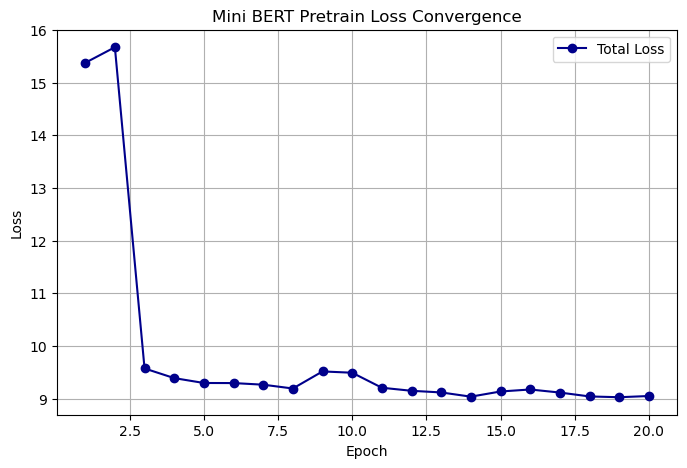

In [10]:
import matplotlib.pyplot as plt

data_to_plot = history_total_loss 

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(data_to_plot) + 1), data_to_plot, marker='o', color='darkblue', label='Total Loss')

plt.title('Mini BERT Pretrain Loss Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True) 
plt.legend()
plt.show()

In [11]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['axes.unicode_minus'] = False

# 데이터 확인
print(f"NSP Loss   기록: {len(history_nsp_loss)}개")
print(f"MLM Loss   기록: {len(history_mlm_loss)}개")
print(f"Total Loss 기록: {len(history_total_loss)}개")
print(f"NSP Acc    기록: {len(history_nsp_acc)}개")
print(f"history_nsp_loss 값: {history_nsp_loss}")

NSP Loss   기록: 20개
MLM Loss   기록: 20개
Total Loss 기록: 20개
NSP Acc    기록: 20개
history_nsp_loss 값: [np.float32(0.5963234), np.float32(0.45685366), np.float32(0.4062134), np.float32(0.3185527), np.float32(0.27130905), np.float32(0.21647368), np.float32(0.18370941), np.float32(0.14715794), np.float32(0.15180387), np.float32(0.2317123), np.float32(0.16120195), np.float32(0.08391532), np.float32(0.04827516), np.float32(0.04784598), np.float32(0.043122474), np.float32(0.04238634), np.float32(0.03215294), np.float32(0.030397264), np.float32(0.03703157), np.float32(0.024745964)]


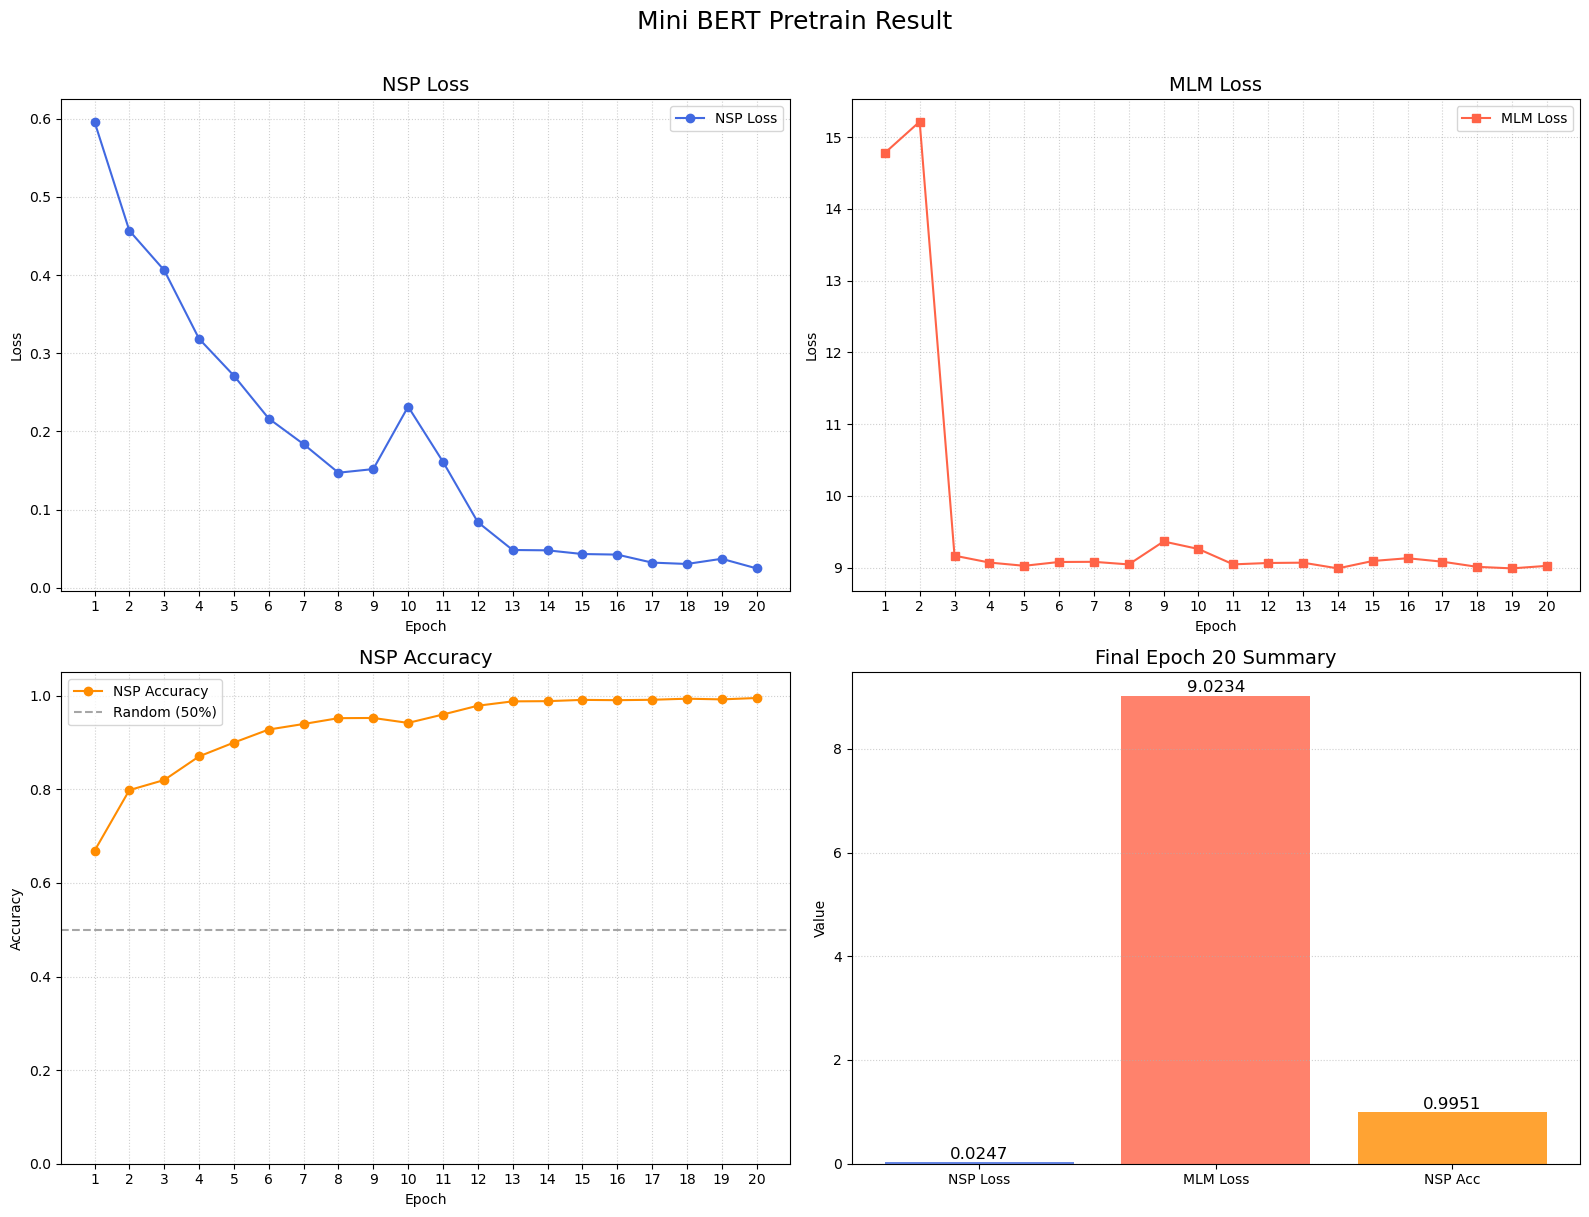

In [12]:
matplotlib.rcParams['axes.unicode_minus'] = False

epoch_range = list(range(1, len(history_nsp_loss) + 1))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Mini BERT Pretrain Result', fontsize=18, y=1.01)

# 그래프 1: NSP Loss만 
axes[0][0].plot(epoch_range, history_nsp_loss, marker='o', color='royalblue', label='NSP Loss')
axes[0][0].set_title('NSP Loss', fontsize=14)
axes[0][0].set_xlabel('Epoch')
axes[0][0].set_ylabel('Loss')
axes[0][0].legend()
axes[0][0].grid(True, linestyle=':', alpha=0.6)
axes[0][0].set_xticks(epoch_range)

# 그래프 2: MLM Loss
axes[0][1].plot(epoch_range, history_mlm_loss, marker='s', color='tomato', label='MLM Loss')
axes[0][1].set_title('MLM Loss', fontsize=14)
axes[0][1].set_xlabel('Epoch')
axes[0][1].set_ylabel('Loss')
axes[0][1].legend()
axes[0][1].grid(True, linestyle=':', alpha=0.6)
axes[0][1].set_xticks(epoch_range)

# 그래프 3: NSP Accuracy 
axes[1][0].plot(epoch_range, history_nsp_acc, marker='o', color='darkorange', label='NSP Accuracy')
axes[1][0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (50%)')
axes[1][0].set_title('NSP Accuracy', fontsize=14)
axes[1][0].set_xlabel('Epoch')
axes[1][0].set_ylabel('Accuracy')
axes[1][0].set_ylim(0, 1.05)
axes[1][0].legend()
axes[1][0].grid(True, linestyle=':', alpha=0.6)
axes[1][0].set_xticks(epoch_range)

# 그래프 4: 최종 요약 막대
final_metrics = [history_nsp_loss[-1], history_mlm_loss[-1], history_nsp_acc[-1]]
metric_labels = ['NSP Loss', 'MLM Loss', 'NSP Acc']
bar_colors    = ['royalblue', 'tomato', 'darkorange']
bars = axes[1][1].bar(metric_labels, final_metrics, color=bar_colors, alpha=0.8)
for bar, val in zip(bars, final_metrics):
    axes[1][1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}', ha='center', va='bottom', fontsize=12
    )
axes[1][1].set_title(f'Final Epoch {epochs} Summary', fontsize=14)
axes[1][1].set_ylabel('Value')
axes[1][1].grid(True, axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### 회고

nsp loss와 mlm loss가 확 낮아져서 문장을 넣었는데, 

문장 연속성을 하는 거는 잘 맞지만, 빈칸 맞추기는 그냥 똑같은 단어만 말해서 때려맞추기라서 수치만큼의 정확도가 없었다.

전에 학습 돌릴때 패딩 마스크에서 get_pad_mask에서 tf.math.equal(tokens, space_id)를 써서 토큰은 가리고 빈칸 패딩에 어텐션하게 하는 오류가 있었어서 그걸 not_equal로 수정해서 다시 학습시킴.

수정 뒤에는 수치적으로 안정화됐으나, mlm은 실제 문장을 넣었을때 잘 되지 않는 것 같다.